In [1]:
%load_ext autoreload
%autoreload 2
import copy, time, sys
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from astropy.io import fits as astropy_fits
from astropy import constants as const

from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

# ==========================================================
#                     PATHS
# ==========================================================

curr_path     = Path().resolve()                  # .../GODMAX/notebooks/tests
PROJECT_ROOT  = curr_path.parents[1]              # GODMAX repo root
DEVELOP       = curr_path.parents[1]              # tSZxEuclid repo root
abs_path_src  = PROJECT_ROOT / "src"
abs_path_data = Path("/home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data")
abs_path_params = DEVELOP / "param_files"
FIGDIR        = curr_path / "plots"
FIGDIR.mkdir(exist_ok=True)

for p in (curr_path, abs_path_src):
    if str(p) not in sys.path:
        sys.path.append(str(p))

from get_Cls import get_Cl
from get_Pkzs import get_Pkz
# from loader import merge_params
import sys, os
# abs_path_data = os.path.abspath(curr_path / "../../data/") 

import numpyro
numpyro.set_platform('cpu')
numpyro.enable_x64()
numpyro.set_host_device_count(jax.device_count())
jax.config.update('jax_enable_x64', True)
print('JAX devices:', jax.local_device_count())

import importlib.util
import get_Cls
# import loader

print("\n--- GODMAX import paths ---")
print("get_Cls imported from:", get_Cls.__file__)
# print("loader imported from :", loader.__file__)

print("\n--- importlib check ---")
print("get_Cls spec:", importlib.util.find_spec("get_Cls").origin)
# print("loader spec :", importlib.util.find_spec("loader").origin)

print("\n--- sys.path entries relevant here ---")
for p in sys.path:
    if "GODMAX" in p or "tSZxEuclid" in p or str(abs_path_src) in p:
        print(p)



/home/vtinnane/micromamba/envs/godmax_test_new/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/vtinnane/micromamba/envs/godmax_test_new/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 508, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/vtinnane/micromamba/envs/godmax_test_new/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/home/vtinnane/micromamba/envs/godmax_test_new/lib/python3.11/site-packages/jax_plugins/xla_cuda12/_

JAX devices: 1

--- GODMAX import paths ---
get_Cls imported from: /home/vtinnane/Documents/Codes/develop/test/test/GODMAX/src/get_Cls.py

--- importlib check ---
get_Cls spec: /home/vtinnane/Documents/Codes/develop/test/test/GODMAX/src/get_Cls.py

--- sys.path entries relevant here ---
/home/vtinnane/Documents/Codes/develop/test/test/GODMAX/notebooks/test
/home/vtinnane/Documents/Codes/develop/test/test/GODMAX/src
/home/vtinnane/Documents/Codes/develop/test/test/GODMAX/src/mcfitjax/cosmology_jax.py


/home/vtinnane/micromamba/envs/godmax_test_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load parameter files
Read the default YAML params and the project-specific `Pge` overrides, then merge (overrides
win) into the four config dicts GODMAX expects: `sim_params` (cosmo + gas + HOD),
`halo_params` (grid resolution), `analysis` (model flags + n(z)), `other_params` (IA / bias).

In [2]:
# =====================================================================
#                         LOAD PARAM FILES
# =====================================================================
import os, yaml

def read_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

params_default = read_yaml(abs_path_params / "params_default.yaml")
params_pge     = read_yaml(abs_path_params / "Pge" / "params_v2.yaml")

# merge simple (overwrite default with pge)
sim_params_dict     = {**params_default["sim_params"], **params_pge["sim_params"]}
halo_params_dict    = {**params_default["halo_params"], **params_pge["halo_params"]}
analysis_dict       = {**params_default["analysis"],    **params_pge["analysis"]}
other_params_dict   = {**params_default["other_params"],**params_pge["other_params"]}


## Cosmology, ℓ and k grids
Build the `jax_cosmo` cosmology from the merged params. Then define the multipole grid
(log-spaced ℓ ∈ [10, 8000]) and the survey k-array — these are required inputs for the
theory C(ℓ) and P(k) calculations and are written back into the config dicts.

In [3]:
# =====================================================================
#                DEFINE COSMOLOGY
# =====================================================================

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )

# =====================================================================
#                DEFINE ELL and K ARRAYs — REQUIRED FOR THEORY
# =====================================================================
lmin, lmax, dl_log_array = 10.0, 8000.0, 0.005325851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array    = l_array_all[1:] - l_array_all[:-1]        # delta ell in each bin
l_array_eff = (l_array_all[1:] + l_array_all[:-1]) / 2. # effective ell in each bin
halo_params_dict['ell_array']    = jnp.array(l_array_eff)
analysis_dict['l_array_survey']  = jnp.array(l_array_eff)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

# ks = np.geomspace(3e-3,10,10) 
# analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

## Redshift distributions n(z)
Load and register the galaxy, lens, and source n(z):

- galaxy n(z) is converted to a **comoving** number density (÷ dV/dz/dΩ),
- 5 normalized lens bins and 5 source bins (same files here) are stacked into the
  `nz_*_info_dict` structures.

The plots show the per-bin n(z); the printed integrals confirm each normalized bin
integrates to ~1.

Original Euclid N(z) files loaded
Integral of raw galaxy nz_gal: 19004.552850950316
Calibrated comoving galaxy nbar range [(Mpc/h)^-3]: 1e-05 0.005
Integral of normalized lens bin 1: 1.0000000000000002
Integral of normalized lens bin 2: 0.9999999999999999
Integral of normalized lens bin 3: 1.0
Integral of normalized lens bin 4: 0.9999999999999999
Integral of normalized lens bin 5: 1.0
Integral of normalized source bin 1: 1.0000000000000002
Integral of normalized source bin 2: 0.9999999999999999
Integral of normalized source bin 3: 1.0
Integral of normalized source bin 4: 0.9999999999999999
Integral of normalized source bin 5: 1.0


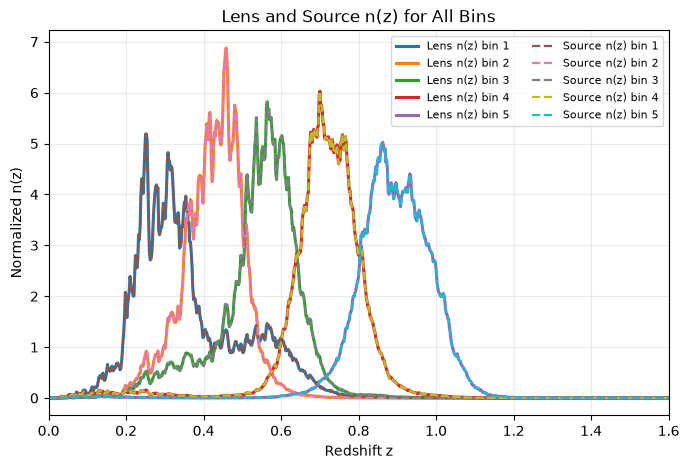

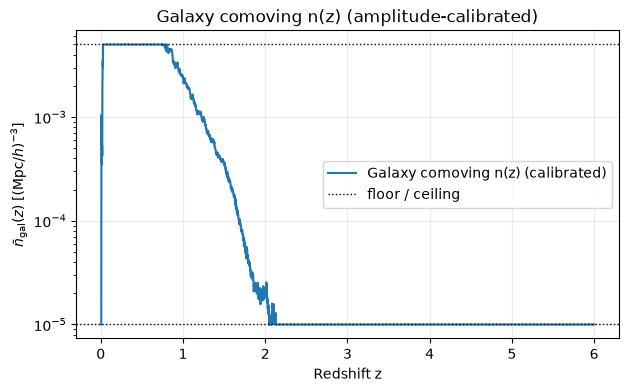

In [4]:
# ==========================================================
#             GALAXY COMOVING NON-NORMALIZED NZ
# ==========================================================

if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz


# ----------------------------------------------------------
# HOD target: nbar_gal_comoving_val is the *comoving* galaxy
# number density [(Mpc/h)^-3] that get_Mthresh inverts against
# the HMF-integrated HOD (see get_radial_profiles.get_Mthresh).
# Expected physical scale ~1e-4..1e-3 (DESI-LRG-like reference).
#
# The raw Euclid forecast file has an unknown absolute normalization
# (its integral is ~1.9e4, not a comoving density). Feeding it directly
# yields nbar ~1e-6 -> get_Mthresh pegs at the interpolation edge.
# So we keep the file's *z-shape* and calibrate the *amplitude* to a
# physical target peak, then clip into the HOD-safe window.
# ----------------------------------------------------------
hod_nbar_comoving_target_peak = 3.0e-2   # (Mpc/h)^-3 ; tune if Euclid sample density is known
hod_nbar_comoving_floor       = 1.0e-5
hod_nbar_comoving_ceiling     = 5.0e-3

# Total lens surface density used for shot noise (nbar_lens_bins downstream).
lsst_y1_lens_nbar_arcmin2_total = 30.0


def to_comoving_nz(z_array, nz_array, cosmo):
    """
    Convert an n(z) shape to a comoving number density shape by
    dividing out the comoving volume element dV/dz/dOmega.

    Returns an *unnormalized* comoving n(z); the absolute amplitude is
    fixed separately by calibrating to a physical target (see below),
    so only the redshift shape of the input matters here.
    """

    z_array = np.asarray(z_array, dtype=float)
    nz_array = np.asarray(nz_array, dtype=float)

    scale_fac_a_array = jnp.asarray(1.0 / (1.0 + z_array))

    chi_array = np.asarray(radial_comoving_distance(cosmo, scale_fac_a_array))
    dchi_dz_array = np.asarray((const.c.value * 1e-3) / bkgrd.H(cosmo, scale_fac_a_array))

    dV_dzdOmega_array = chi_array**2 * dchi_dz_array

    nz_comoving = np.divide(
        nz_array,
        dV_dzdOmega_array,
        out=np.zeros_like(nz_array),
        where=dV_dzdOmega_array > 0.0,
    )

    return nz_comoving


# Load the original non-normalized Euclid galaxy n(z)
dndz_gal_file = np.loadtxt(
    abs_path_data / "dndz" / "nz_euclid_forecast_bin-all.txt"
)

z_gal = np.asarray(dndz_gal_file[:, 0], dtype=float)
nz_gal = np.asarray(dndz_gal_file[:, 1], dtype=float)

# Remove z = 0 point if present, because dV/dz/dOmega = 0 at z = 0
mask_gal = z_gal > 0.0
z_gal = z_gal[mask_gal]
nz_gal = nz_gal[mask_gal]

nz_gal = np.nan_to_num(nz_gal, nan=0.0, posinf=0.0, neginf=0.0)
nz_gal = np.clip(nz_gal, 0.0, None)

# Comoving shape (unnormalized amplitude)
nz_gal_comoving_raw = to_comoving_nz(z_gal, nz_gal, cosmo_jax)

# Calibrate amplitude to a physical target peak, then clip into HOD-safe window.
peak_raw = float(np.max(nz_gal_comoving_raw))
if peak_raw <= 0.0:
    raise ValueError("Comoving galaxy n(z) is non-positive everywhere")
nz_gal_comoving = nz_gal_comoving_raw * (hod_nbar_comoving_target_peak / peak_raw)
nz_gal_comoving = np.clip(
    nz_gal_comoving,
    hod_nbar_comoving_floor,
    hod_nbar_comoving_ceiling,
)

analysis_dict["nbar_gal_comoving_zarray"] = z_gal
analysis_dict["nbar_gal_comoving_val"] = nz_gal_comoving


# ==========================================================
#                     LENS NZ BINS
# ==========================================================

nz_lens = {}
nz_lens_info_dict = {}

nbins_lens = 5
nz_lens_info_dict["nbins_lens"] = nbins_lens

z_lens = None

for nbin in range(nbins_lens):

    nz_lens_nbin = np.loadtxt(
        abs_path_data / "dndz" / f"nz_norm_euclid_forecast_bin-{nbin + 1}.txt"
    )

    z_this = np.asarray(nz_lens_nbin[:, 0], dtype=float)
    nz_this = np.asarray(nz_lens_nbin[:, 1], dtype=float)

    nz_this = np.nan_to_num(nz_this, nan=0.0, posinf=0.0, neginf=0.0)
    nz_this = np.clip(nz_this, 0.0, None)

    norm_this = np.trapezoid(nz_this, z_this)

    if norm_this <= 0.0:
        raise ValueError(f"Lens bin {nbin + 1} has non-positive integral")

    nz_this = nz_this / norm_this

    if z_lens is None:
        z_lens = z_this
    else:
        if not np.allclose(z_lens, z_this):
            raise ValueError(f"Lens bin {nbin + 1} has a different redshift grid")

    nz_lens[nbin] = nz_this
    nz_lens_info_dict[f"nz{nbin}"] = nz_lens[nbin]

nz_lens_info_dict["z_array_lens"] = z_lens
analysis_dict["nz_lens_info_dict"] = nz_lens_info_dict

# Per-bin lens surface density [arcmin^-2] (used downstream for shot noise).
lens_bin_nbar_arcmin2 = np.full(
    nbins_lens, lsst_y1_lens_nbar_arcmin2_total / nbins_lens
)


# ==========================================================
#                     SOURCE NZ BINS
# ==========================================================

nz_source = {}
nz_source_info_dict = {}

nbins_source = 5
nz_source_info_dict["nbins"] = nbins_source

z_source = None

for nbin in range(nbins_source):

    nz_source_nbin = np.loadtxt(
        abs_path_data / "dndz" / f"nz_norm_euclid_forecast_bin-{nbin + 1}.txt"
    )

    z_this = np.asarray(nz_source_nbin[:, 0], dtype=float)
    nz_this = np.asarray(nz_source_nbin[:, 1], dtype=float)

    nz_this = np.nan_to_num(nz_this, nan=0.0, posinf=0.0, neginf=0.0)
    nz_this = np.clip(nz_this, 0.0, None)

    norm_this = np.trapezoid(nz_this, z_this)

    if norm_this <= 0.0:
        raise ValueError(f"Source bin {nbin + 1} has non-positive integral")

    nz_this = nz_this / norm_this

    if z_source is None:
        z_source = z_this
    else:
        if not np.allclose(z_source, z_this):
            raise ValueError(f"Source bin {nbin + 1} has a different redshift grid")

    nz_source[nbin] = nz_this
    nz_source_info_dict[f"nz{nbin}"] = nz_source[nbin]

nz_source_info_dict["z_array_source"] = z_source
analysis_dict["nz_source_info_dict"] = nz_source_info_dict


# ==========================================================
#                     REDSHIFT SUPPORT
# ==========================================================

# zmax is governed by the parameter file:
#   halo_params.zmax   -> the halo z-grid (base_class z_array)
#   analysis.zmax_for_Cls -> the projection grid
# Do NOT override them here. The galaxy all-bin n(z) spans to z=6,
# and forcing the halo grid that far drives Mdmb/gas <= 0 -> log() NaN
# in get_Ptot -> all of y3d_mat NaN. Leave the param-file value (1.6).
zmax_plot = float(min(max(z_lens[-1], z_source[-1]),
                      float(halo_params_dict.get('zmax', 1.6))))  # x-limit for plots only


# ==========================================================
#                     CHECKS AND PLOTS
# ==========================================================

print("Original Euclid N(z) files loaded", flush=True)

print("Integral of raw galaxy nz_gal:", np.trapezoid(nz_gal, z_gal))
print(
    "Calibrated comoving galaxy nbar range [(Mpc/h)^-3]:",
    float(np.min(nz_gal_comoving)),
    float(np.max(nz_gal_comoving)),
)
_frac_at_floor = float(np.mean(nz_gal_comoving <= hod_nbar_comoving_floor))
if _frac_at_floor > 0.5:
    print(
        f"WARNING: {_frac_at_floor:.0%} of comoving nbar sits at the floor "
        f"({hod_nbar_comoving_floor:.1e}); raise hod_nbar_comoving_target_peak."
    )

for i in range(nbins_lens):
    print(
        f"Integral of normalized lens bin {i + 1}:",
        np.trapezoid(nz_lens[i], z_lens),
    )

for i in range(nbins_source):
    print(
        f"Integral of normalized source bin {i + 1}:",
        np.trapezoid(nz_source[i], z_source),
    )


fig, ax = plt.subplots(figsize=(8, 5))

for i in range(nbins_lens):
    ax.plot(z_lens, nz_lens[i], label=f"Lens n(z) bin {i + 1}", lw=2.2)

for i in range(nbins_source):
    ax.plot(z_source, nz_source[i], "--", label=f"Source n(z) bin {i + 1}", lw=1.6)

ax.set_xlabel("Redshift z")
ax.set_ylabel("Normalized n(z)")
ax.set_title("Lens and Source n(z) for All Bins")
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.25)
ax.set_xlim(0.0, zmax_plot)

plt.show()


plt.figure(figsize=(7, 4))
plt.plot(z_gal, nz_gal_comoving, label="Galaxy comoving n(z) (calibrated)")
plt.axhline(hod_nbar_comoving_floor, color="k", ls=":", lw=1, label="floor / ceiling")
plt.axhline(hod_nbar_comoving_ceiling, color="k", ls=":", lw=1)
plt.xlabel("Redshift z")
plt.ylabel(r"$\bar{n}_{\rm gal}(z)\;[(\mathrm{Mpc}/h)^{-3}]$")
plt.title("Galaxy comoving n(z) (amplitude-calibrated)")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## Lens-bin number densities
Use the absolute LSST Y1 lens surface-density amplitude from the n(z) setup cell and
store the per-bin values as `nbar_lens_bins`. These set the shot-noise level for the
galaxy probes.

In [5]:
nbar_lens_bins = np.asarray(lens_bin_nbar_arcmin2, dtype=float)
analysis_dict['nbar_lens_bins'] = nbar_lens_bins
print('Lens-bin densities [arcmin^-2]:', nbar_lens_bins)

Lens-bin densities [arcmin^-2]: [6. 6. 6. 6. 6.]


In [6]:
# from scipy.interpolate import interp1d

# deg2_to_arcmin2 = 3600.0

# nz_gal_interp = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
# nz_gal_on_zlens = nz_gal_interp(z_lens)

# # stack normalized bin PDFs
# pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])   # shape (nbins, Nz)
# pz_sum = np.sum(pz_bins, axis=0)

# nbar_lens_bins = np.zeros(nbins_lens)

# for jb in range(nbins_lens):
#     frac_j = np.zeros_like(z_lens)
#     valid = pz_sum > 0
#     frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]

#     nbar_deg2 = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens)
#     nbar_lens_bins[jb] = nbar_deg2 / deg2_to_arcmin2

# analysis_dict['nbar_lens_bins'] = nbar_lens_bins

## Build the C(ℓ) object
Instantiate `get_Cl` with the four config dicts. This runs the full inheritance chain
(`base_class → Profiles → get_Pkz → get_Cl`): profiles, 3D power spectra, and angular power
spectra are all computed here and cached on the returned `cls` object.

In [7]:
# pk = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
cls = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)




In [8]:
# ==========================================================
#   NaN HUNT: find the first profile matrix that breaks u_y
# ==========================================================
import numpy as np

print("model_tSZ:", cls.model_tSZ, " nr,nz,nM:", cls.nr, cls.nz, cls.nM)
_r = np.asarray(cls.r_array)
print("r_array range:", float(_r.min()), float(_r.max()),
      " -> log(r_min) finite?", bool(np.isfinite(np.log(_r.min()))))

chain = [
    "r200c_mat", "conc_Mz_mat", "fgas_mat", "fclm_mat",
    "rho_gas_mat", "rho_clm_mat", "rho_cga_mat", "rho_dmb_mat",
    "Mgas_mat", "Mclm_mat", "Mdmb_mat", "Mtot_mat",
    "Ptot_mat_physical", "Pe_mat_physical", "y3d_mat",
]
for name in chain:
    a = getattr(cls, name, None)
    if a is None:
        print(f"{name:20s} MISSING")
        continue
    a = np.asarray(a)
    print(
        f"{name:20s} shape={str(a.shape):18s} "
        f"nan%={np.mean(np.isnan(a)):.3f} nonpos%={np.mean(a <= 0):.3f} "
        f"min={np.nanmin(a):.2e} max={np.nanmax(a):.2e}"
    )
# The FIRST row with nan%>0 is where the NaN is born.
# If the row just above it shows nonpos%>0 on Mdmb_mat / rho_gas_mat,
# that <=0 feeds log() in get_Ptot (get_radial_profiles.py:936) -> NaN.

model_tSZ: True  nr,nz,nM: 24 22 24
r_array range: 0.0004999999999999999 16.0  -> log(r_min) finite? True
r200c_mat            shape=(22, 24)           nan%=0.000 nonpos%=0.000 min=1.12e-01 max=3.42e+00
conc_Mz_mat          shape=(22, 24)           nan%=0.000 nonpos%=0.000 min=3.45e+00 max=9.20e+00
fgas_mat             shape=(22, 24)           nan%=0.000 nonpos%=0.000 min=1.48e-01 max=1.60e-01
fclm_mat             shape=(22, 24)           nan%=0.000 nonpos%=0.000 min=8.40e-01 max=8.44e-01
rho_gas_mat          shape=(24, 22, 24)       nan%=0.000 nonpos%=0.000 min=1.07e+04 max=8.61e+14
rho_clm_mat          shape=(24, 22, 24)       nan%=0.000 nonpos%=0.002 min=0.00e+00 max=2.26e+18
rho_cga_mat          shape=(24, 22, 24)       nan%=0.000 nonpos%=0.336 min=0.00e+00 max=4.33e+18
rho_dmb_mat          shape=(24, 22, 24)       nan%=0.000 nonpos%=0.000 min=1.07e+04 max=6.13e+18
Mgas_mat             shape=(24, 22, 24)       nan%=0.000 nonpos%=0.042 min=0.00e+00 max=9.52e+14
Mclm_mat             

## Matter power decomposition & baryonic ratios
Pull the cached P(k,z) matrices off `cls` and plot, at several redshifts:

- **Left:** the components — halofit, NFW total, DMB total, and the DMB 1-halo / 2-halo split.
  Colour family = component, shade = redshift (lighter → darker = low → high z).
- **Right:** the baryonic-modification ratios `P_DMB/P_NFW` and `P_tot/P_halofit`, which show
  the suppression relative to the no-bary baselines.

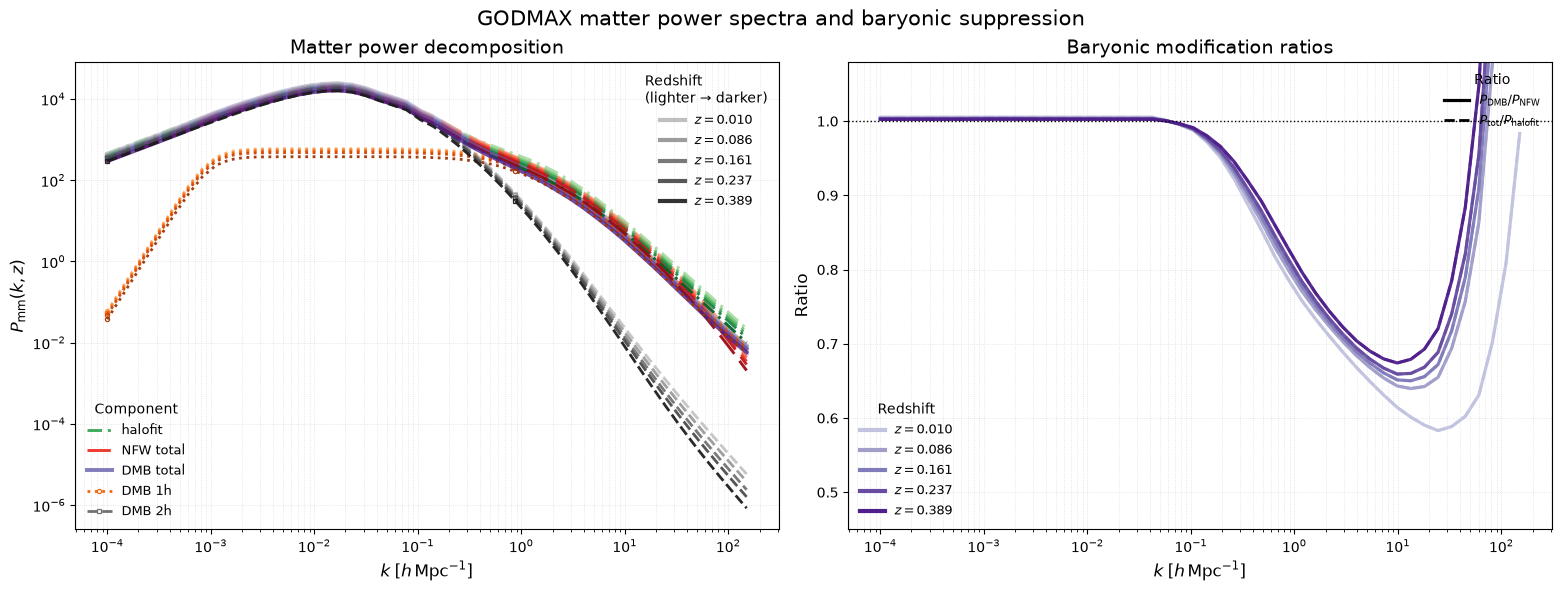

In [9]:
# ── Arrays ────────────────────────────────────────────────────────────────
k     = np.asarray(cls.kPk_array)
z_arr = np.asarray(cls.z_array)

Pnfwtot  = np.asarray(cls.Pmm_nfw_tot_mat)
Pdmbltot = np.asarray(cls.Pmm_dmb_tot_mat)
Pdmb_1h  = np.asarray(cls.Pmm_dmb_1h_kz_mat)
Pdmb_2h  = np.asarray(cls.Pmm_dmb_2h_kz_mat)
Phfit    = np.asarray(cls.phfit_kz_mat)
Psup     = np.asarray(cls.Pmm_sup_tot_mat)
Ptot     = np.asarray(cls.Pmm_tot_mat)

# Redshift indices to plot
z_indices = [0, 1, 2, 3, 5]
z_indices = [iz for iz in z_indices if iz < len(z_arr)]

# Ensure they are ordered in increasing z
z_indices = sorted(z_indices, key=lambda i: z_arr[i])

# ── Helpers ───────────────────────────────────────────────────────────────
def positive_for_log(y):
    """
    Mask non-positive values for log plotting.
    """
    y = np.asarray(y, dtype=float)
    return np.where(y > 0, y, np.nan)

def safe_ratio(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    return np.divide(
        num, den,
        out=np.full_like(num, np.nan, dtype=float),
        where=np.isfinite(den) & (den != 0)
    )

# ── Colour families for each component ────────────────────────────────────
# light -> dark corresponds to low z -> high z
shade_values = np.linspace(0.35, 0.90, len(z_indices))

component_cmaps = {
    "DMB total": plt.cm.Purples,
    "NFW total": plt.cm.Reds,
    "halofit":   plt.cm.Greens,
    "DMB 1h":    plt.cm.Oranges,
    "DMB 2h":    plt.cm.Greys,  
}

# Build per-component, per-redshift colours
component_colors = {
    comp: {
        iz: cmap(shade_values[j])
        for j, iz in enumerate(z_indices)
    }
    for comp, cmap in component_cmaps.items()
}

# ── Styles for decomposition plot ─────────────────────────────────────────
component_styles = {
    "halofit": {
        "ls": (0, (5, 2, 1, 2)),   # dash-dot
        "lw": 2.1,
        "marker": None,
    },
    "NFW total": {
        "ls": (0, (8, 3)),         # long dashed
        "lw": 2.1,
        "marker": None,
    },
    "DMB total": {
        "ls": "-",                 # solid
        "lw": 2.8,
        "marker": None,
    },
    "DMB 1h": {
        "ls": ":",
        "lw": 2.0,
        "marker": "o",
        "ms": 3.0,
        "markevery": 30,
        "markerfacecolor": "none",
        "markeredgewidth": 0.9,
    },
    "DMB 2h": {
        "ls": "--",
        "lw": 2.0,
        "marker": "s",
        "ms": 3.0,
        "markevery": 30,
        "markerfacecolor": "none",
        "markeredgewidth": 0.9,
    },
}

# ── Styles for ratio plot ─────────────────────────────────────────────────
# Here we keep a simpler scheme: redshift = purple shade, ratio = linestyle
ratio_styles = {
    r"$P_{\rm DMB}/P_{\rm NFW}$": {
        "ls": "-",
        "lw": 2.3,
    },
    r"$P_{\rm tot}/P_{\rm halofit}$": {
        "ls": "--",
        "lw": 2.0,
    },
}

ratio_cmap = plt.cm.Purples
ratio_colors = {
    iz: ratio_cmap(shade_values[j])
    for j, iz in enumerate(z_indices)
}

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(15.5, 5.8),
    constrained_layout=True
)

# =========================================================================
# Panel 1: Matter power decomposition
# =========================================================================
ax = axes[0]

for iz in z_indices:
    ax.loglog(
        k, positive_for_log(Phfit[:, iz]),
        color=component_colors["halofit"][iz],
        alpha=0.95,
        **component_styles["halofit"]
    )

    ax.loglog(
        k, positive_for_log(Pnfwtot[:, iz]),
        color=component_colors["NFW total"][iz],
        alpha=0.95,
        **component_styles["NFW total"]
    )

    ax.loglog(
        k, positive_for_log(Pdmbltot[:, iz]),
        color=component_colors["DMB total"][iz],
        alpha=0.8,
        **component_styles["DMB total"]
    )

    ax.loglog(
        k, positive_for_log(Pdmb_1h[:, iz]),
        color=component_colors["DMB 1h"][iz],
        alpha=0.95,
        **component_styles["DMB 1h"]
    )

    ax.loglog(
        k, positive_for_log(Pdmb_2h[:, iz]),
        color=component_colors["DMB 2h"][iz],
        alpha=0.95,
        **component_styles["DMB 2h"]
    )

ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$", fontsize=12)
ax.set_ylabel(r"$P_{\rm mm}(k,z)$", fontsize=12)
ax.set_title("Matter power decomposition", fontsize=14)
ax.grid(True, which="both", ls=":", lw=0.6, alpha=0.4)

# Legend 1: component meaning (colour family + line style)
component_handles = []
for comp, style in component_styles.items():
    # use the middle shade of each component family for the legend
    iz_mid = z_indices[len(z_indices)//2]
    component_handles.append(
        Line2D(
            [0], [0],
            color=component_colors[comp][iz_mid],
            ls=style["ls"],
            lw=style["lw"],
            marker=style.get("marker", None),
            markersize=style.get("ms", 0),
            markerfacecolor=style.get("markerfacecolor", "none"),
            markeredgecolor=component_colors[comp][iz_mid],
            markeredgewidth=style.get("markeredgewidth", 1.0),
            label=comp
        )
    )

leg1 = ax.legend(
    handles=component_handles,
    title="Component",
    fontsize=9,
    title_fontsize=10,
    loc="lower left",
    frameon=False
)
ax.add_artist(leg1)

# Legend 2: redshift shading guide
# use neutral grey shades to explain light -> dark mapping
grey_shades = np.linspace(0.75, 0.20, len(z_indices))
z_handles = [
    Line2D(
        [0], [0],
        color=str(grey_shades[j]),
        lw=3.0,
        label=rf"$z={z_arr[iz]:.3f}$"
    )
    for j, iz in enumerate(z_indices)
]

ax.legend(
    handles=z_handles,
    title="Redshift\n(lighter → darker)",
    fontsize=9,
    title_fontsize=10,
    loc="upper right",
    frameon=False
)

# =========================================================================
# Panel 2: Ratios
# =========================================================================
ax = axes[1]

for iz in z_indices:
    c = ratio_colors[iz]

    ratio_dmb_nfw  = safe_ratio(Pdmbltot[:, iz], Pnfwtot[:, iz])
    ratio_tot_hfit = safe_ratio(Ptot[:, iz], Phfit[:, iz])

    ax.semilogx(
        k, ratio_dmb_nfw,
        color=c,
        alpha=0.95,
        **ratio_styles[r"$P_{\rm DMB}/P_{\rm NFW}$"]
    )

    ax.semilogx(
        k, ratio_tot_hfit,
        color=c,
        alpha=0.80,
        **ratio_styles[r"$P_{\rm tot}/P_{\rm halofit}$"]
    )

ax.axhline(1.0, color="k", lw=1.0, ls=":")
ax.set_ylim(0.45, 1.08)

ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$", fontsize=12)
ax.set_ylabel("Ratio", fontsize=12)
ax.set_title("Baryonic modification ratios", fontsize=14)
ax.grid(True, which="both", ls=":", lw=0.6, alpha=0.4)

# Ratio legend
ratio_handles = [
    Line2D(
        [0], [0],
        color="k",
        ls=style["ls"],
        lw=style["lw"],
        label=name
    )
    for name, style in ratio_styles.items()
]

leg2 = ax.legend(
    handles=ratio_handles,
    title="Ratio",
    fontsize=9,
    title_fontsize=10,
    loc="upper right",
    frameon=False
)
ax.add_artist(leg2)

# Redshift legend for ratio panel
ratio_z_handles = [
    Line2D(
        [0], [0],
        color=ratio_colors[iz],
        lw=3.0,
        label=rf"$z={z_arr[iz]:.3f}$"
    )
    for iz in z_indices
]

ax.legend(
    handles=ratio_z_handles,
    title="Redshift",
    fontsize=9,
    title_fontsize=10,
    loc="lower left",
    frameon=False
)

# ── Overall title and save ────────────────────────────────────────────────
fig.suptitle(
    "GODMAX matter power spectra and baryonic suppression",
    fontsize=15
)

fig.savefig(
    FIGDIR / "Pmm_decomposition_component_hues.png",
    bbox_inches="tight",
    dpi=180
)

plt.show()

## Fourier-profile mass-conservation check
Diagnostic: every normalized Fourier profile must satisfy **u(k→0) = 1** (mass conservation).

- The printout compares the code's actual `u_DMB(k→0)` against the target 1.0, and reports the
  **window ratio** `M_grid[r_min,r_max] / M_tot[0.01,16·r200c]` — the root cause of an earlier
  overshoot (u_DMB → ~1.8) when the fixed FFT grid didn't match the per-halo normalization window.
- The 5-panel figure shows `u_DMB`, `u_NFW`, `u_CLM`, `u_ne`, and `u_y` vs k across halo masses;
  each should approach the dashed line at 1 on large scales.

u_DMB(k->0)  [code actual]   min=0.964  max=0.991   (target 1.000)
window ratio M_grid/Mtot     min=0.889  max=1.752
worst window: z=0.010  logM=11.50  ratio=1.752   16*r200c=1.79 Mpc  vs rmax=16.00 Mpc
the shapes:  (22, 24) (22, 24)


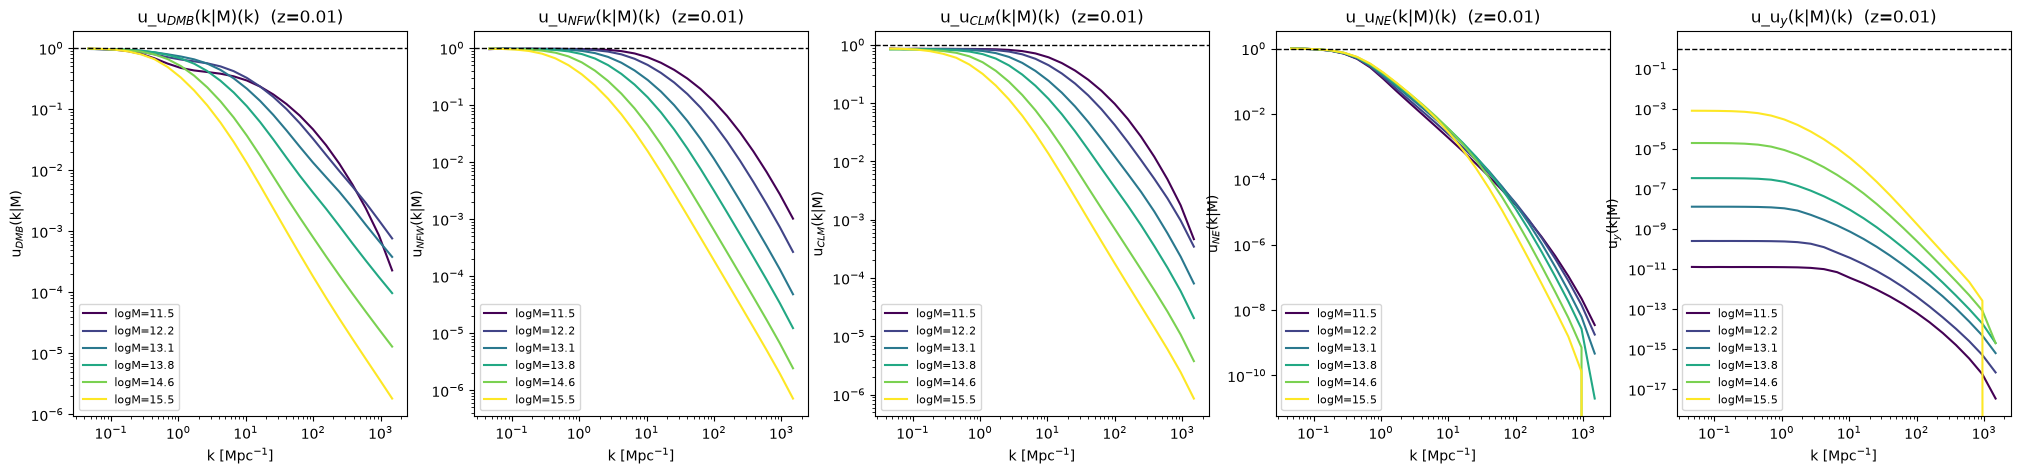

In [10]:
# ======================================================================
#   DIAGNOSTIC + FIX CHECK:  is the DMB Fourier profile mass-conserving?
#   u_DMB(k|M) = FFTLog(rho_dmb / norm).  Low-k limit MUST equal 1.
#
#   Panel A : the code's ACTUAL u_DMB(k)  (uk_dmb_tointp).
#             -> BEFORE fix it overshoots to ~1.8 at low-M/low-z.
#             -> AFTER fix (rho_dmb / Mdmb_grid in get_Pkzs) it sits on 1.
#   Panel B : INVESTIGATION of the window mismatch that caused it:
#             ratio = M_grid[rmin,rmax] / Mtot[0.01,16*r200c].
#             ratio>1  -> grid extends past 16*r200c, gas tail leaks IN.
#             ratio<1  -> grid truncates before 16*r200c, mass cut OFF.
#   (Panel B is computed from rho/Mtot directly, so it shows the underlying
#    window shift regardless of which normalisation the code currently uses.)
# ======================================================================

obj  = cls                                     # has Profiles+get_Pkz attrs
r    = np.array(obj.r_array)
z    = np.array(obj.z_array)
M    = np.array(obj.M_array); lgM = np.log10(M)
Mtot = np.array(obj.Mtot_mat)
r200 = np.array(obj.r200c_mat)

# Panel A: the code's actual Fourier profile on the mcfit k-grid
k_mc   = np.array(obj.k_mcfit)
uk_dmb = np.array(obj.uk_dmb_tointp)               # [nk_mcfit, nz, nM]
klo    = int(np.argmin(k_mc))
u0     = uk_dmb[klo, :, :]                         # ~ u_DMB(k->0)

# Panel B: window-shift investigation (grid mass vs Mtot window)
Mgrid_dmb = np.trapezoid(4*np.pi*r[:,None,None]**2*np.array(obj.rho_dmb_mat), x=r, axis=0)
ratio     = Mgrid_dmb / Mtot

print(f"u_DMB(k->0)  [code actual]   min={u0.min():.3f}  max={u0.max():.3f}   (target 1.000)")
print(f"window ratio M_grid/Mtot     min={ratio.min():.3f}  max={ratio.max():.3f}")
imax = np.unravel_index(np.argmax(ratio), ratio.shape)
print(f"worst window: z={z[imax[0]]:.3f}  logM={lgM[imax[1]]:.2f}  "
      f"ratio={ratio[imax]:.3f}   16*r200c={16*r200[imax]:.2f} Mpc  vs rmax={r[-1]:.2f} Mpc")

# fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# jz  = 0
# sel = np.linspace(0, len(M)-1, 6).astype(int)
# for c, jM in zip(plt.cm.viridis(np.linspace(0,1,len(sel))), sel):
#     ax[0].loglog(k_mc, uk_dmb[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")
# ax[0].axhline(1.0, ls="--", c="k", lw=1)
# ax[0].set(xlabel="k [Mpc$^{-1}$]", ylabel="u$_{DMB}$(k|M)",
#           title=f"u_DMB(k)  (z={z[jz]:.2f})")
# ax[0].legend(fontsize=8)

# for jz_ in range(len(z)):
#     ax[1].plot(lgM, ratio[jz_,:], "o-", ms=3, label=f"z={z[jz_]:.2f}")
# ax[1].axhline(1.0, ls="--", c="k", lw=1)
# ax[1].set(xlabel="log$_{10}$ M",
#           ylabel="$M_{grid}[r_{min},r_{max}] / M_{tot}[16 r_{200c}]$",
#           title="B: window mismatch (cause)")
# ax[1].legend(fontsize=7, ncol=2); ax[1].grid(alpha=.3)
# plt.tight_layout()
# plt.savefig(FIGDIR / "uDMB_k0_diagnostic.png", dpi=110)
# plt.show()

#plot the radial profiles of gg and yy
uk_nfw = np.array(obj.uk_nfw_tointp)               # [nk_mcfit, nz, nM]
klo    = int(np.argmin(k_mc))
unfw     = uk_nfw[klo, :, :]  

uk_clm = np.array(obj.uk_clm_tointp)               # [nk_mcfit, nz, nM]
klo    = int(np.argmin(k_mc))
uclm     = uk_clm[klo, :, :]  

uk_ne = np.array(obj.uk_ne_tointp)               # [nk_mcfit, nz, nM]
klo    = int(np.argmin(k_mc))
une     = uk_ne[klo, :, :]  

uk_y = np.array(obj.uk_y_tointp)               # [nk_mcfit, nz, nM]
klo    = int(np.argmin(k_mc))
u0     = uk_y[klo, :, :]  

print("the shapes: ", uclm.shape, une.shape)

fig, ax = plt.subplots(1, 5, figsize=(25, 5))
jz = 0
sel = np.linspace(0, len(M)-1, 6).astype(int)
for c, jM in zip(plt.cm.viridis(np.linspace(0,1,len(sel))), sel):
    ax[0].loglog(k_mc, uk_dmb[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")
    ax[1].loglog(k_mc, uk_nfw[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")
    ax[2].loglog(k_mc, uk_clm[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")
    ax[3].loglog(k_mc, uk_ne[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")
    ax[4].loglog(k_mc, uk_y[:,jz,jM], color=c, label=f"logM={lgM[jM]:.1f}")

labels = ["u$_{DMB}$(k|M)", "u$_{NFW}$(k|M)", "u$_{CLM}$(k|M)", "u$_{NE}$(k|M)", "u$_{y}$(k|M)"]
for i in range(5):
    ax[i].axhline(1.0, ls="--", c="k", lw=1)
    ax[i].set(xlabel="k [Mpc$^{-1}$]", ylabel=labels[i],
          title=f"u_{labels[i]}(k)  (z={z[jz]:.2f})")
    ax[i].legend(fontsize=8)

plt.savefig(FIGDIR / "u_profiles_k0.png", dpi=110)

In [11]:

import copy

halo_params_dict['do_corr_2h_mm'] = True
# ── Baryonified run ────────────────────────────────────────────────────────────
ad_bary = copy.deepcopy(analysis_dict)
ad_bary['model_matter']    = 'DMB'     # κκ: baryonified halo model × S(k,z)
ad_bary['backreaction']     = True      # κκ: baryonified halo model × S(k,z)

print('Building baryonified Cl ...')
pk_bary = get_Pkz(sim_params_dict, halo_params_dict, ad_bary, other_params_dict)
cl_bary = get_Cl(sim_params_dict, halo_params_dict, ad_bary, other_params_dict,  Pkz_obj=pk_bary)
print('Done.')

# ── No-baryonification baseline ────────────────────────────────────────────────
# κκ  : model_matter='halofit' (existing flag, unchanged)
# gκ  : matter leg rho_dmb -> rho_nfw         (new baryonification=False)
# κy/gy/yy: pressure leg NFW replacements     (new baryonification=False)
ad_nobary = copy.deepcopy(analysis_dict)
ad_nobary['model_matter']    = 'halofit'     # κκ: halofit (existing flag, unchanged)
ad_nobary['backreaction']     = False

print('Building no-baryonification baseline Cl ...')
pk_nobary = get_Pkz(sim_params_dict, halo_params_dict, ad_nobary, other_params_dict)
cl_nobary = get_Cl(sim_params_dict, halo_params_dict, ad_nobary, other_params_dict,  Pkz_obj=pk_nobary)
print('Done.')

ell = np.array(cl_bary.ell_array)
print(f'ell range: {ell[0]:.1f} – {ell[-1]:.1f},  nell={len(ell)}')
print(f'nbins source={cl_bary.nbins},  nbins lens={cl_bary.nbins_lens}')


Building baryonified Cl ...
Done.
Building no-baryonification baseline Cl ...
Done.
ell range: 10.0 – 7973.4,  nell=1255
nbins source=5,  nbins lens=5


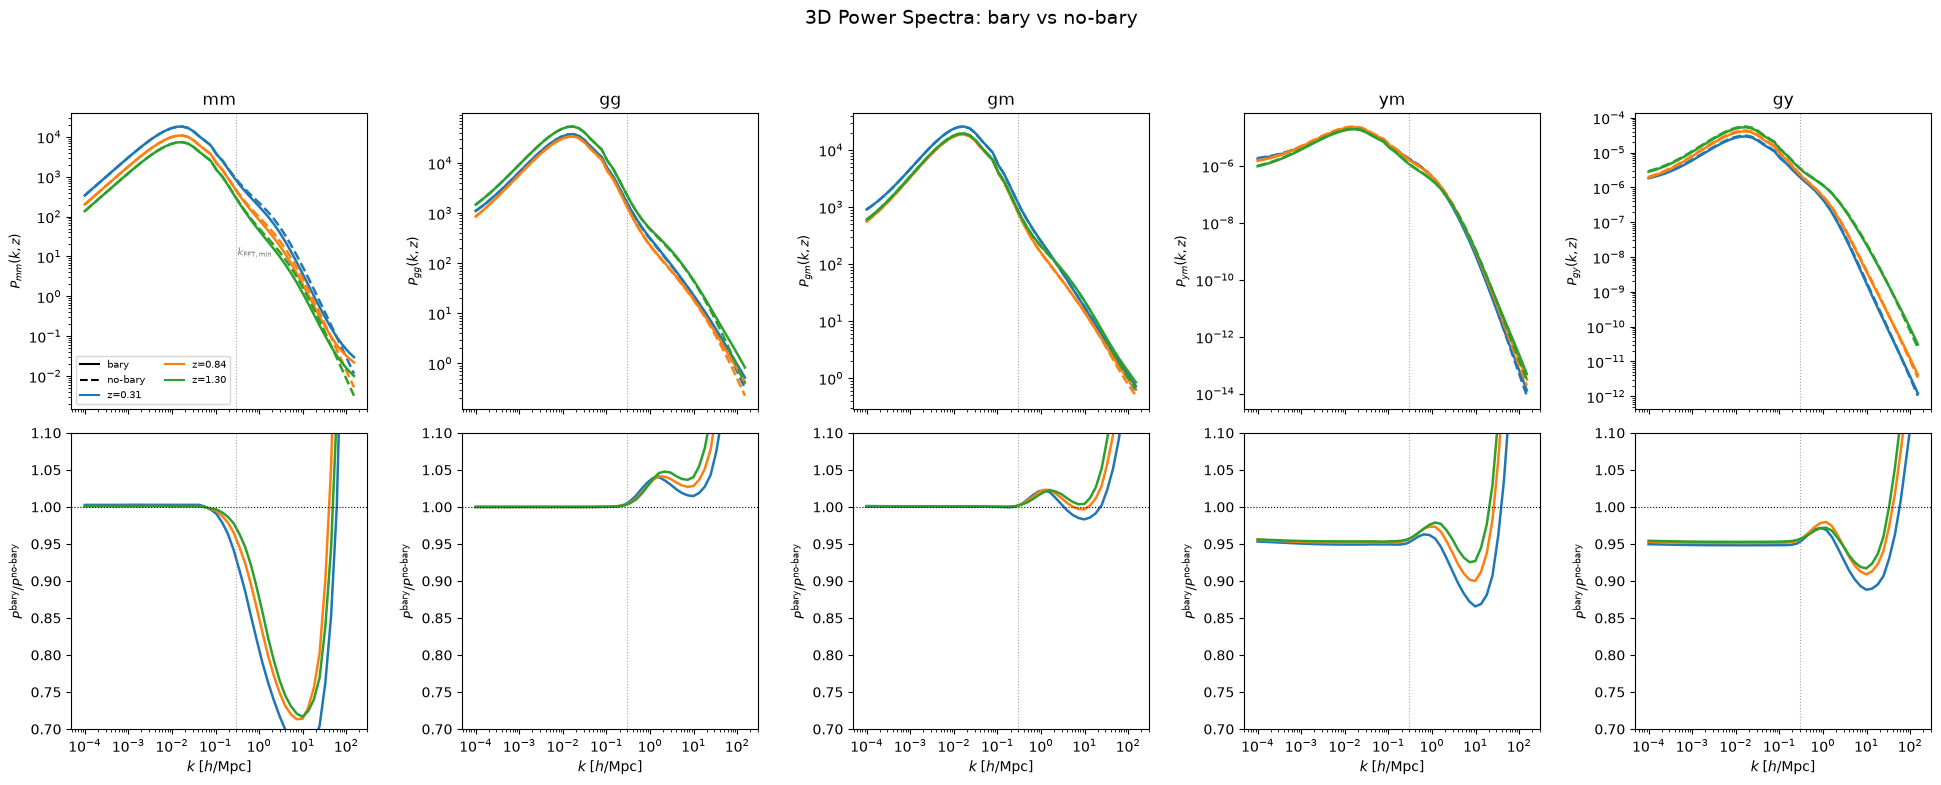

Saved → /home/vtinnane/Documents/Codes/develop/test/test/GODMAX/notebooks/test/plots/baryonification_Pk.png


In [12]:
# ── 3D Power Spectra: P(k,z) bary vs no-bary ──────────────────────────────────
# Rows: P(k,z) | ratio P_bary/P_nobary
# Cols: mm (κκ) | gg | yy | gm (gκ matter leg) | ym (κy matter×pressure) | gy

k     = np.array(cl_bary.kPk_array)
z_arr = np.array(cl_bary.z_array)

# 3 representative redshift slices
iz_picks = [len(z_arr) // 5, len(z_arr) // 2, 4 * len(z_arr) // 5]
z_picks  = z_arr[iz_picks]
zcols    = ['C0', 'C1', 'C2']

PK_PROBES = [
    ('mm',  r'$P_{mm}(k,z)$',   'Pmm_tot_mat'),
    ('gg',  r'$P_{gg}(k,z)$',   'Pgg_tot_mat'),
    # ('yy',  r'$P_{yy}(k,z)$',   'Pyy_tot_kz_mat'),
    ('gm',  r'$P_{gm}(k,z)$',   'Pgm_tot_mat'),
    ('ym',  r'$P_{ym}(k,z)$',   'Pym_tot_mat'),
    ('gy',  r'$P_{gy}(k,z)$',   'Pgy_tot_mat'),
]

fig, axes = plt.subplots(2, 5, figsize=(24, 8),
                          gridspec_kw={'hspace': 0.08, 'wspace': 0.32})

for col, (pkey, ylabel, attr) in enumerate(PK_PROBES):
    ax_pk  = axes[0, col]
    ax_rat = axes[1, col]

    Pk_b  = np.array(getattr(cl_bary,   attr))   # [nk, nz]
    Pk_nb = np.array(getattr(cl_nobary, attr))    # [nk, nz]

    for zcol, iz in zip(zcols, iz_picks):
        z_val   = z_arr[iz]
        pb  = np.abs(Pk_b[:,  iz])
        pnb = np.abs(Pk_nb[:, iz])

        ax_pk.loglog(k, pb,  color=zcol, lw=1.8,        label=f'z={z_val:.2f}')
        ax_pk.loglog(k, pnb, color=zcol, lw=1.8, ls='--')

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(pnb > 0, pb / pnb, np.nan)
        ax_rat.semilogx(k, ratio, color=zcol, lw=1.8)

    # ── top panel ──
    ax_pk.set_title(pkey, fontsize=12)
    ax_pk.set_ylabel(ylabel, fontsize=9)
    ax_pk.tick_params(labelbottom=False)

    if col == 0:
        leg_lines = [
            plt.Line2D([0],[0], color='k', lw=1.5,        label='bary'),
            plt.Line2D([0],[0], color='k', lw=1.5, ls='--', label='no-bary'),
        ] + [plt.Line2D([0],[0], color=c, lw=1.5, label=f'z={z_arr[iz]:.2f}')
             for c, iz in zip(zcols, iz_picks)]
        ax_pk.legend(handles=leg_lines, fontsize=7, loc='lower left', ncol=2)

    # ── bottom panel ──
    ax_rat.axhline(1, color='k', lw=0.8, ls=':')
    ax_rat.set_xlabel(r'$k\;[h/\mathrm{Mpc}]$', fontsize=10)
    ax_rat.set_ylabel(r'$P^{\rm bary}/P^{\rm no\text{-}bary}$', fontsize=9)
    ax_rat.set_ylim(0.7, 1.1)

    # mark k_mcfit lower bound
    k_mcfit0 = 0.291
    for ax in [ax_pk, ax_rat]:
        ax.axvline(k_mcfit0, color='gray', lw=0.8, ls=':', alpha=0.7)
    if col == 0:
        ax_rat.text(k_mcfit0 * 1.1, 1.35, r'$k_{\rm FFT,min}$',
                    fontsize=7, color='gray', va='top')

fig.suptitle(r'3D Power Spectra: bary vs no-bary', fontsize=14, y=1.01)
plt.savefig(str(FIGDIR / 'baryonification_Pk.png'), bbox_inches='tight')
plt.show()
print(f'Saved → {FIGDIR / "baryonification_Pk.png"}')


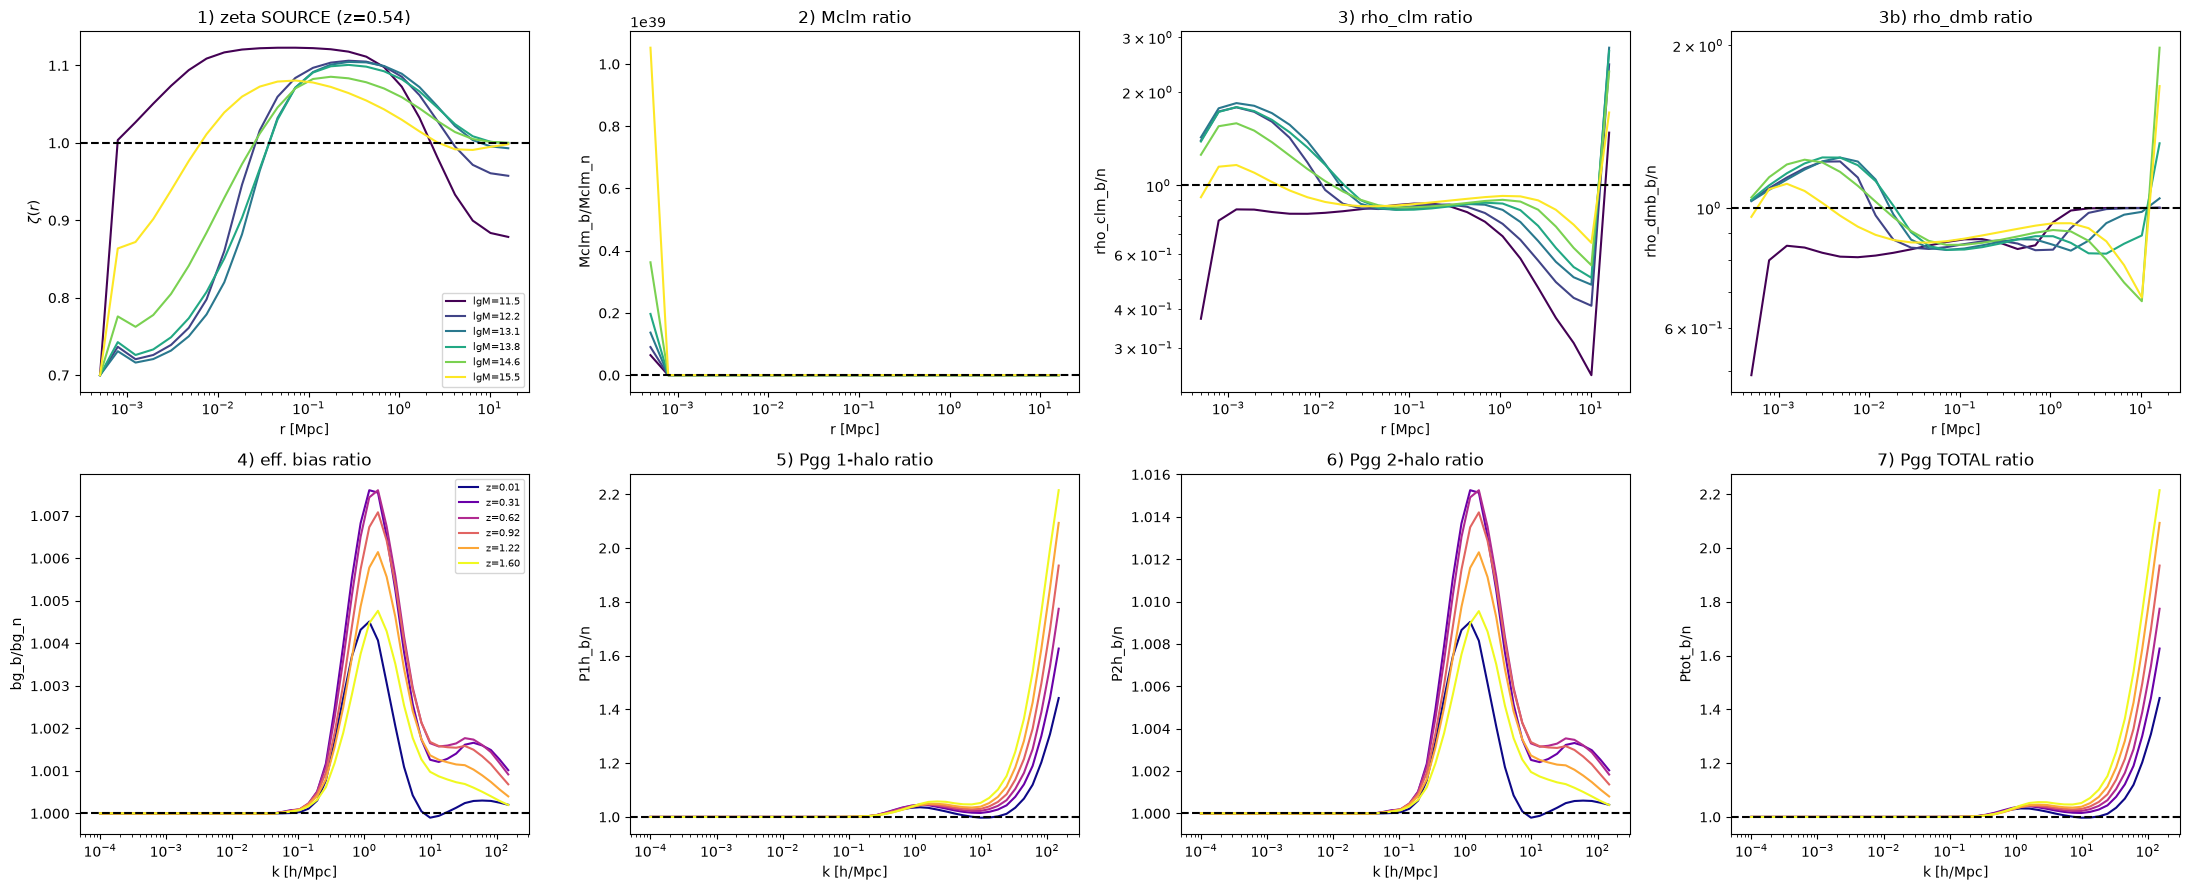

z(radial panels) = 0.540
zeta range          : 0.7 - 1.1251
Mclm ratio range    : 0.6481 - 1.8193501203135148e+39
max|bg ratio - 1|   : 0.007651312144683953
max|P2h ratio - 1|  : 0.015361166866903364
max|P1h ratio - 1|  : 1.2152718540059686


In [13]:
# ======================================================================
#  WHERE DOES gg DIVERGE? Walk the chain bary/nobary, upstream -> downstream.
#
#   zeta(r)      [backreaction source; nobary => zeta==1]
#     -> Mclm(r) [contracted collisionless mass]
#       -> rho_clm(r) / rho_dmb(r)  [density that gets FFT'd -> u_clm(k)]
#         -> bg(k)  [effective galaxy bias = 2-halo amplitude]
#           -> Pgg_1h(k), Pgg_2h(k)
#             -> Pgg_tot(k)
#  Top row: radial (vs r) at fixed z.  Bottom row: k-space at a few z.
# ======================================================================
import numpy as np, matplotlib.pyplot as plt

B, N = cl_bary, cl_nobary
r   = np.array(B.r_array)
k   = np.array(B.kPk_array)
z   = np.array(B.z_array)
M   = np.array(B.M_array); lgM = np.log10(M)
jz  = len(z)//3                                   # one redshift for radial panels
selM = np.linspace(0, len(M)-1, 6).astype(int)
cols = plt.cm.viridis(np.linspace(0, 1, len(selM)))

zeta = np.array(B.zeta_mat)                        # (nr,nz,nM); only bary has it
Mclm_b, Mclm_n = np.array(B.Mclm_mat), np.array(N.Mclm_mat)
rdmb_b, rdmb_n = np.array(B.rho_dmb_mat), np.array(N.rho_dmb_mat)
rclm_b, rclm_n = np.array(B.rho_clm_mat), np.array(N.rho_clm_mat)
bg_b, bg_n     = np.array(B.bg_kz_mat), np.array(N.bg_kz_mat)        # (nk,nz)
P1_b, P1_n     = np.array(B.Pgg_1h_kz_mat), np.array(N.Pgg_1h_kz_mat)
P2_b, P2_n     = np.array(B.Pgg_2h_kz_mat), np.array(N.Pgg_2h_kz_mat)
Pt_b, Pt_n     = np.array(B.Pgg_tot_mat), np.array(N.Pgg_tot_mat)

fig, ax = plt.subplots(2, 4, figsize=(22, 9))

# --- TOP ROW: radial source (vs r) at z=z[jz] ---
for c, jM in zip(cols, selM):
    ax[0,0].semilogx(r, zeta[:,jz,jM], color=c, label=f"lgM={lgM[jM]:.1f}")
    ax[0,1].semilogx(r, Mclm_b[:,jz,jM]/Mclm_n[:,jz,jM], color=c)
    ax[0,2].loglog(r, rclm_b[:,jz,jM]/np.clip(rclm_n[:,jz,jM],1e-300,None), color=c)
    ax[0,3].loglog(r, rdmb_b[:,jz,jM]/np.clip(rdmb_n[:,jz,jM],1e-300,None), color=c)
ax[0,0].axhline(1,ls="--",c="k"); ax[0,0].set(xlabel="r [Mpc]", ylabel=r"$\zeta(r)$", title=f"1) zeta SOURCE (z={z[jz]:.2f})"); ax[0,0].legend(fontsize=7)
ax[0,1].axhline(1,ls="--",c="k"); ax[0,1].set(xlabel="r [Mpc]", ylabel="Mclm_b/Mclm_n", title="2) Mclm ratio")
ax[0,2].axhline(1,ls="--",c="k"); ax[0,2].set(xlabel="r [Mpc]", ylabel="rho_clm_b/n", title="3) rho_clm ratio")
ax[0,3].axhline(1,ls="--",c="k"); ax[0,3].set(xlabel="r [Mpc]", ylabel="rho_dmb_b/n", title="3b) rho_dmb ratio")

# --- BOTTOM ROW: k-space, a few z slices ---
selz = np.linspace(0, len(z)-1, 6).astype(int)
zc   = plt.cm.plasma(np.linspace(0,1,len(selz)))
for c, iz in zip(zc, selz):
    ax[1,0].semilogx(k, bg_b[:,iz]/bg_n[:,iz], color=c, label=f"z={z[iz]:.2f}")
    ax[1,1].semilogx(k, P1_b[:,iz]/P1_n[:,iz], color=c)
    ax[1,2].semilogx(k, P2_b[:,iz]/P2_n[:,iz], color=c)
    ax[1,3].semilogx(k, Pt_b[:,iz]/Pt_n[:,iz], color=c)
ax[1,0].axhline(1,ls="--",c="k"); ax[1,0].set(xlabel="k [h/Mpc]", ylabel="bg_b/bg_n", title="4) eff. bias ratio"); ax[1,0].legend(fontsize=7)
ax[1,1].axhline(1,ls="--",c="k"); ax[1,1].set(xlabel="k [h/Mpc]", ylabel="P1h_b/n", title="5) Pgg 1-halo ratio")
ax[1,2].axhline(1,ls="--",c="k"); ax[1,2].set(xlabel="k [h/Mpc]", ylabel="P2h_b/n", title="6) Pgg 2-halo ratio")
ax[1,3].axhline(1,ls="--",c="k"); ax[1,3].set(xlabel="k [h/Mpc]", ylabel="Ptot_b/n", title="7) Pgg TOTAL ratio")

plt.tight_layout(); plt.show()

print(f"z(radial panels) = {z[jz]:.3f}")
print("zeta range          :", round(float(zeta.min()),4), "-", round(float(zeta.max()),4))
print("Mclm ratio range    :", round(float((Mclm_b/Mclm_n).min()),4), "-", round(float((Mclm_b/Mclm_n).max()),4))
print("max|bg ratio - 1|   :", float(np.nanmax(np.abs(bg_b/bg_n-1))))
print("max|P2h ratio - 1|  :", float(np.nanmax(np.abs(P2_b/P2_n-1))))
print("max|P1h ratio - 1|  :", float(np.nanmax(np.abs(P1_b/P1_n-1))))


In [14]:
for nm in ['Ncen_mat','Nsat_mat','hmf_Mz_mat','bias_Mz_mat','nbarz']:
      a, b = np.array(getattr(B,nm)), np.array(getattr(N,nm))
      print(f"{nm:12s} allclose={np.allclose(a,b)}  max|r-1|={np.nanmax(np.abs(a/np.clip(b,1e-300,None)-1)):.2e}")

ukc_b, ukc_n = np.array(B.uk_clm), np.array(N.uk_clm)   # (nk,nz,nM)
print("uk_clm[k0] bary  min/max:", float(ukc_b[0].min()), float(ukc_b[0].max()))
print("uk_clm[k0] noba  min/max:", float(ukc_n[0].min()), float(ukc_n[0].max()))
print("bg ratio @k0 mean:", float(np.nanmean(np.array(B.bg_kz_mat)[0]/np.array(N.bg_kz_mat)[0])))



Ncen_mat     allclose=True  max|r-1|=0.00e+00
Nsat_mat     allclose=True  max|r-1|=0.00e+00
hmf_Mz_mat   allclose=True  max|r-1|=0.00e+00
bias_Mz_mat  allclose=True  max|r-1|=0.00e+00
nbarz        allclose=True  max|r-1|=0.00e+00
uk_clm[k0] bary  min/max: 0.9999999999999999 1.0
uk_clm[k0] noba  min/max: 0.9999999999999999 1.0
bg ratio @k0 mean: 1.0


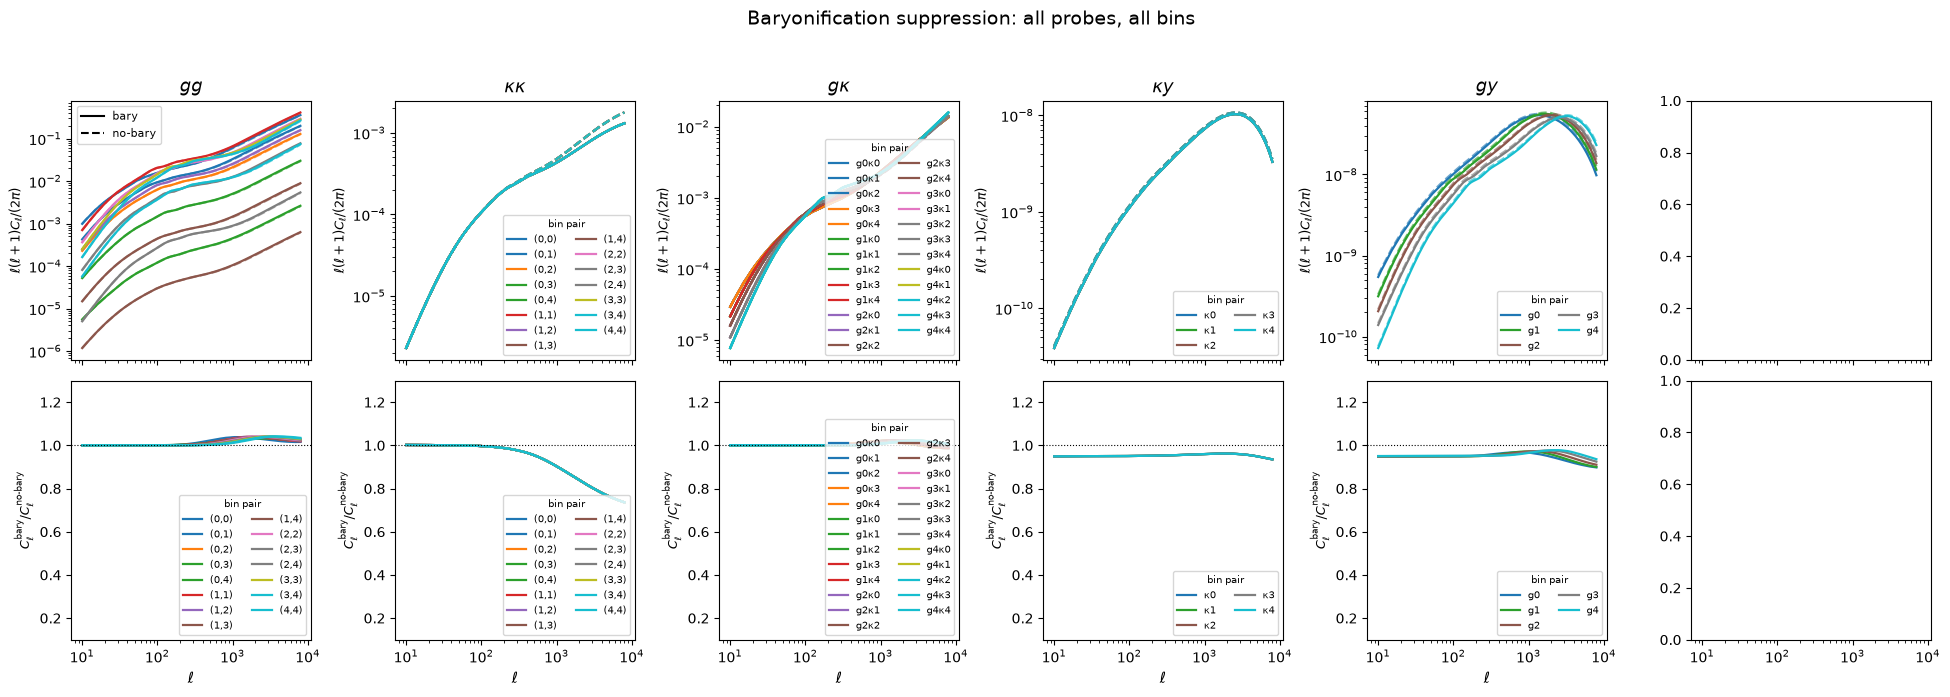

Saved → /home/vtinnane/Documents/Codes/develop/test/test/GODMAX/notebooks/test/plots/baryonification_ratio.png


In [15]:

# ── Baryonification test: C_ℓ^bary vs C_ℓ^no-bary — ALL bin combinations ─────
#
# Layout: 2 rows × 6 cols
#   Row 0 : Dℓ = ℓ(ℓ+1)Cℓ/2π  (bary solid, no-bary dashed)
#   Row 1 : ratio Cℓ^bary / Cℓ^no-bary
#
# All unique bin pairs shown per probe (colour-coded).
# ─────────────────────────────────────────────────────────────────────────────

PROBES  = ['gg', 'kk', 'gk', 'ky', 'gy']
TITLES  = [r'$gg$', r'$\kappa\kappa$',
           r'$g\kappa$', r'$\kappa y$', r'$gy$']

nbins_s = cl_bary.nbins        # source / kappa bins   (=1)
nbins_l = cl_bary.nbins_lens   # lens  / galaxy bins   (=2)


def get_cl(cl_obj, probe, ib1, ib2=0):
    """Return Cℓ array for probe and bin indices (ib1, ib2)."""
    if probe == 'kk':
        return np.array(cl_obj.Cl_kappa_kappa_tot_mat[:, ib1, ib2])
    elif probe == 'gg':
        return np.array(cl_obj.Cl_gal_gal_tot_mat[:, ib1, ib2])
    elif probe == 'yy':
        return np.array(cl_obj.Cl_y_y_signal_mat)
    elif probe == 'gk':
        return np.array(cl_obj.Cl_gal_kappa_tot_mat[:, ib1, ib2])
    elif probe == 'ky':
        return np.array(cl_obj.Cl_kappa_y_tot_mat[:, ib1])
    elif probe == 'gy':
        return np.array(cl_obj.Cl_gal_y_tot_mat[:, ib1])
    else:
        raise ValueError(probe)


def bin_pairs(probe, nbins_l, nbins_s):
    """Return list of (ib1, ib2, label) for all unique bin pairs."""
    if probe == 'gg':
        return [(i, j, f'({i},{j})') for i in range(nbins_l)
                for j in range(i, nbins_l)]
    elif probe == 'kk':
        return [(i, j, f'({i},{j})') for i in range(nbins_s)
                for j in range(i, nbins_s)]
    elif probe == 'yy':
        return [(0, 0, 'yy')]
    elif probe == 'gk':
        return [(i, j, f'g{i}κ{j}') for i in range(nbins_l)
                for j in range(nbins_s)]
    elif probe == 'ky':
        return [(i, 0, f'κ{i}') for i in range(nbins_s)]
    elif probe == 'gy':
        return [(i, 0, f'g{i}') for i in range(nbins_l)]


fig, axes = plt.subplots(
    2, 6, figsize=(24, 7),
    sharex=True,
    gridspec_kw={'hspace': 0.08, 'wspace': 0.35}
)

for col, (probe, title) in enumerate(zip(PROBES, TITLES)):
    ax_cl  = axes[0, col]
    ax_rat = axes[1, col]

    pairs = bin_pairs(probe, nbins_l, nbins_s)
    cmap  = plt.get_cmap('tab10', max(len(pairs), 1))

    for pidx, (ib1, ib2, lbl) in enumerate(pairs):
        color = cmap(pidx)
        cl_b  = get_cl(cl_bary,   probe, ib1, ib2)
        cl_nb = get_cl(cl_nobary, probe, ib1, ib2)

        Dl_b  = ell * (ell + 1) / (2 * np.pi) * np.abs(cl_b)
        Dl_nb = ell * (ell + 1) / (2 * np.pi) * np.abs(cl_nb)

        ax_cl.loglog(ell, Dl_b,  color=color, lw=1.6,        label=lbl)
        ax_cl.loglog(ell, Dl_nb, color=color, lw=1.6, ls='--', alpha=0.65)

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(np.abs(cl_nb) > 0, cl_b / cl_nb, np.nan)
        ax_rat.semilogx(ell, ratio, color=color, lw=1.6, label=lbl)

    # ── top panel ──
    ax_cl.set_title(title, fontsize=13)
    ax_cl.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$', fontsize=9)
    ax_cl.tick_params(labelbottom=False)
    if len(pairs) > 1:
        ax_cl.legend(fontsize=7, loc='lower right', ncol=2,
                     title='bin pair', title_fontsize=7)
    if col == 0:
        leg_lines = [
            plt.Line2D([0],[0], color='k', lw=1.5,        label='bary'),
            plt.Line2D([0],[0], color='k', lw=1.5, ls='--', label='no-bary'),
        ]
        ax_cl.legend(handles=leg_lines, fontsize=8, loc='upper left')

    # ── bottom panel ──
    ax_rat.axhline(1, color='k', lw=0.8, ls=':')
    ax_rat.set_xlabel(r'$\ell$', fontsize=11)
    ax_rat.set_ylabel(r'$C_\ell^{\rm bary}/C_\ell^{\rm no\text{-}bary}$', fontsize=9)
    ax_rat.set_ylim(0.1, 1.3)
    if len(pairs) > 1:
        ax_rat.legend(fontsize=7, loc='lower right', ncol=2,
                      title='bin pair', title_fontsize=7)

fig.suptitle('Baryonification suppression: all probes, all bins', fontsize=14, y=1.01)
plt.savefig(str(FIGDIR / 'baryonification_ratio.png'), bbox_inches='tight')
plt.show()
print(f'Saved → {FIGDIR / "baryonification_ratio.png"}')
